# Разведовательный Анализ данных по «СберАвтоподписка»

## План работы

### 1. Проведите подготовительную работу:
1) Прочитайте предоставленный датасет.
2) Ознакомьтесь с описаниями представленных атрибутов.
3) Оцените полноту и чистоту данных. Попытайтесь понять, что стоит за этими данными в реальном мире. Приведите данные в удобный\нормальный вид для дальнейшей работы.
            
### 2. Проведите разведочный анализ данных:
1) Проведите базовую чистку (дубликаты, пустые значения, типизация данных, ненужные атрибуты).
2) Посмотрите на распределение ключевых атрибутов, их отношения.

### 3. ML:
1) Обучить модель предсказывать совершение целевого действия (ориентировочное значение ROC-AUC ~ 0.65) — факт совершения пользователем целевого действия.
2) Упаковка получившуюся модель в сервис, который будет брать на вход все атрибуты, типа utm_*, device_*, geo_*, и отдавать на выход 0/1 (1 — если пользователь совершит любое целевое действие).
3) Оценка качества

# Описание дата сетов

## GA Sessions (ga_sessions.pkl)

Одна строка = один визит на сайт.
### Описание атрибутов:
    session_id — ID визита;
    client_id — ID посетителя;
    visit_date — дата визита;
    visit_time — время визита;
    visit_number — порядковый номер визита клиента;
    utm_source — канал привлечения;
    utm_medium — тип привлечения;
    utm_cam paign — рекламная кампания;
    utm_key word — ключевое слово;
    device_category — тип устройства;
    device_os — ОС устройства;
    device_brand — марка устройства;
    device_model — модел ь устройства;
    device_screen_resolution — разре шение экрана;
    device_brand — марка устройства;
    device_model — модель устройства;
    device_screen_resolution — разрешение экрана;
    device_browser — браузер;
    geo_country — страна;
    geo_city — город.

## GA Hits (ga_hits.pkl)
    Одна строка = одно событие в рамках одного визита на сайт.

### Описание атрибутов:
    session_id — ID визита;
    hit_date — дата события;
    hit_time — время события;
    hit_number — порядковый номер события в рамках сессии;
    hit_ty pe — тип события;
    hit_re ferer — источник события;
    hit_ page_path — страница события;
    event_category — тип действия;
    event_action — действие;
    event_label — тег действия;
    event_value — зна чение результата действия.

# Ход Работы

#### Импорт Библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve


#### Открываем фаилы 

In [2]:
df_sessions = pd.read_csv("D:/DATA_сеты/Final_work_'Data_Science'/ga_sessions.csv", low_memory=False)
df_sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [3]:
df_hist = pd.read_csv("D:/DATA_сеты/Final_work_'Data_Science'/ga_hits.csv", low_memory=False)
df_hist.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


## Подготовка данных

In [4]:
# Исходная информация
print(f"--- Исходная информация ---\n {'/' * 42}")
print(f"{df_sessions.info()} \n {'/' * 42}")
print(f"{df_hist.info()} \n {'/' * 42}")

# Проверка дата сетов на пропуски
print(f"--- Пропуски перед первичной чисткой ---\n {'/' * 42}")
print(f"Пропуски в сессиях:\n {df_sessions.isna().sum()} \n{'/' * 42}")
print(f"Пропуски в хитах:\n {df_hist.isna().sum()}")

--- Исходная информация ---
 //////////////////////////////////////////
<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype
---  ------                    -----
 0   session_id                str  
 1   client_id                 str  
 2   visit_date                str  
 3   visit_time                str  
 4   visit_number              int64
 5   utm_source                str  
 6   utm_medium                str  
 7   utm_campaign              str  
 8   utm_adcontent             str  
 9   utm_keyword               str  
 10  device_category           str  
 11  device_os                 str  
 12  device_brand              str  
 13  device_model              str  
 14  device_screen_resolution  str  
 15  device_browser            str  
 16  geo_country               str  
 17  geo_city                  str  
dtypes: int64(1), str(17)
memory usage: 593.3 MB
None 
 //////////////////////////////

##### Очистка и типизация df_sessions & df_hits

In [5]:
# Удаляем полные дубликаты строк
df_sessions = df_sessions.drop_duplicates()

# Приводим дату и время к правильному формату
# Объединяем дату и время в один признак для удобства анализа во времени
df_sessions['visit_datetime'] = pd.to_datetime(df_sessions['visit_date'] + ' ' + df_sessions['visit_time'], errors='coerce')
df_sessions['visit_date'] = pd.to_datetime(df_sessions['visit_date'], errors='coerce')

# Заполнение очевидных пропусков в ОС по бренду устройства
# Если бренд Xiaomi, Huawei, Samsung — это 100% Android
android_brands = ['Xiaomi', 'Huawei', 'Samsung']
df_sessions.loc[df_sessions['device_os'].isna() & df_sessions['device_brand'].isin(android_brands), 'device_os'] = 'Android'

# Заполняем остальные строковые пропускы заглушкой 'unknown'
text_cols_sessions = ['utm_campaign', 'utm_adcontent', 'utm_keyword', 'device_os', 'device_model']
df_sessions[text_cols_sessions] = df_sessions[text_cols_sessions].fillna('unknown')

# Печать очищенного дата-сета
df_sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,visit_datetime
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,unknown,360x720,Chrome,Russia,Zlatoust,2021-11-24 14:36:32
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,unknown,385x854,Samsung Internet,Russia,Moscow,2021-11-14 08:21:30
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,unknown,360x720,Chrome,Russia,Krasnoyarsk,2021-12-28 02:42:06
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,unknown,NOBKLgtuvqYWkXQHeYWM,unknown,mobile,Android,Xiaomi,unknown,393x786,Chrome,Russia,Moscow,2021-05-29 05:00:00
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,unknown,unknown,unknown,mobile,Android,Xiaomi,unknown,393x786,Chrome,Russia,Moscow,2021-05-29 05:00:00


In [6]:
# Удаляем полные дубликаты строк
df_hist = df_hist.drop_duplicates()

# Приводим дату к datetime
df_hist['hit_date'] = pd.to_datetime(df_hist['hit_date'], errors='coerce')

# Переводим hit_time из миллисекунд в минуты от начала сессии (для удобства EDA)
df_hist['hit_time_mins'] = df_hist['hit_time'] / 1000 / 60

# Заполняем пропуски в категориальных признаках хитов
text_cols_hits = ['hit_referer', 'event_label']
df_hist[text_cols_hits] = df_hist[text_cols_hits].fillna('unknown')

# Печать очищенного дата-сета
df_hist.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value,hit_time_mins
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,unknown,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,unknown,NaN,9.964400
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,unknown,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,unknown,NaN,9.955517
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,unknown,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,unknown,NaN,13.270867
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,unknown,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,unknown,NaN,15.571533
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,unknown,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,unknown,NaN,12.812350


In [7]:
# Проверяем результат
print(f"--- После первичной чистки ---\n {'/' * 42}")
print(f"Пропуски в сессиях:\n{df_sessions.isna().sum()}\n {'/' * 42}")
print(f"Пропуски в хитах:\n{df_hist.isna().sum()}")

--- После первичной чистки ---
 //////////////////////////////////////////
Пропуски в сессиях:
session_id                       0
client_id                        0
visit_date                       0
visit_time                       0
visit_number                     0
utm_source                      97
utm_medium                       0
utm_campaign                     0
utm_adcontent                    0
utm_keyword                      0
device_category                  0
device_os                        0
device_brand                367178
device_model                     0
device_screen_resolution         0
device_browser                   0
geo_country                      0
geo_city                         0
visit_datetime                   0
dtype: int64
 //////////////////////////////////////////
Пропуски в хитах:
session_id               0
hit_date                 0
hit_time           9160322
hit_number               0
hit_type                 0
hit_referer              0
hit

In [8]:
# Доочистка
df_sessions['utm_source'] = df_sessions['utm_source'].fillna('unknown')
df_sessions['device_brand'] = df_sessions['device_brand'].fillna('unknown')

# Удаляем абсолютно пустой признак из хитов для экономии памяти
if 'event_value' in df_hist.columns:
    df_hist = df_hist.drop(columns=['event_value'])

##### Создание целевой переменной

In [9]:
# Список целевых действий
target_actions = [
    'sub_car_claim_click', 'sub_car_claim_submit_click',
    'sub_open_dialog_click', 'sub_custom_question_submit_click',
    'sub_call_number_click', 'sub_callback_submit_click', 
    'sub_submit_success', 'sub_car_request_submit_click'
]

# Находим session_id, в которых совершено хотя бы одно целевое действие
target_sessions = df_hist[df_hist['event_action'].isin(target_actions)]['session_id'].unique()

# Создаем таргет в таблице сессий: 1 если session_id в списке целевых, иначе 0
df_sessions['target'] = df_sessions['session_id'].isin(target_sessions).astype(int)

# Проверяем баланс классов
conversion_rate = df_sessions['target'].mean() * 100
print(f"Общее количество сессий: {len(df_sessions)}")
print(f"Количество целевых сессий (конверсий): {df_sessions['target'].sum()}")
print(f"Конверсия (CR): {conversion_rate:.2f}%")


Общее количество сессий: 1860042
Количество целевых сессий (конверсий): 50314
Конверсия (CR): 2.70%


## Изучение распределений ключевых атрибутов

C:\Users\serge\AppData\Local\Temp\ipykernel_11236\878327327.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_sessions[df_sessions['visit_number'] <= 10],


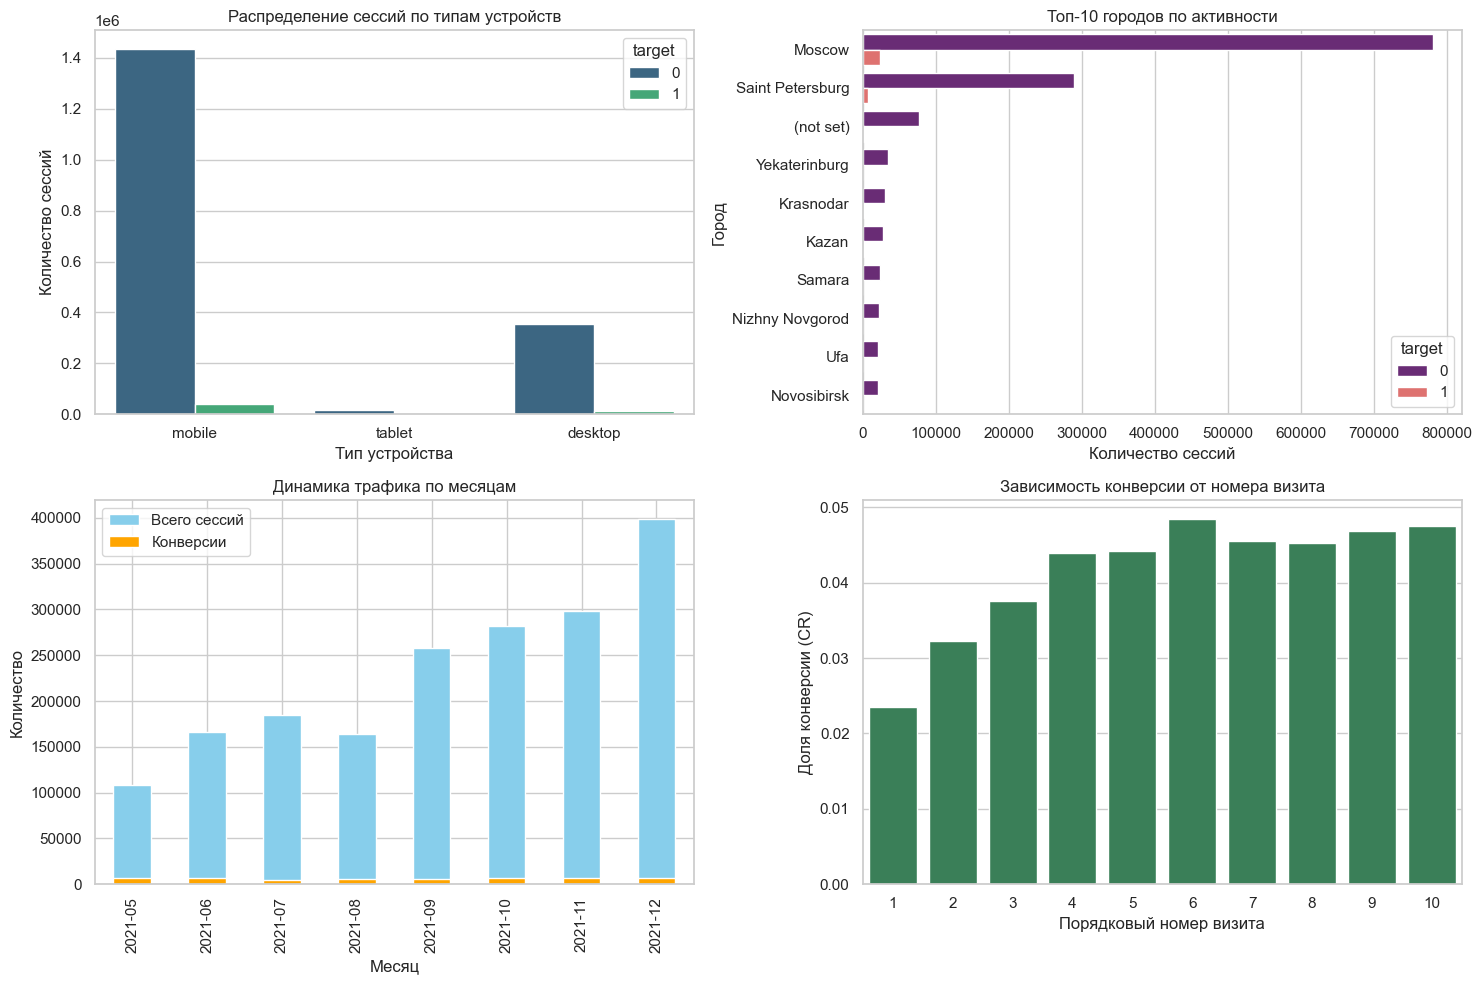

In [10]:
# Стиль графиков
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# График 1: Распределение по типам устройств (Device Category) в разрезе конверсии
plt.subplot(2, 2, 1)
sns.countplot(data=df_sessions, x='device_category', hue='target', palette='viridis')
plt.title('Распределение сессий по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Количество сессий')

# График 2: Топ-10 городов по количеству сессий
plt.subplot(2, 2, 2)
top_cities = df_sessions['geo_city'].value_counts().head(10).index
sns.countplot(data=df_sessions[df_sessions['geo_city'].isin(top_cities)], 
              y='geo_city', hue='target', order=top_cities, palette='magma')
plt.title('Топ-10 городов по активности')
plt.xlabel('Количество сессий')
plt.ylabel('Город')

# График 3: Динамика трафика и конверсий по месяцам
df_sessions['month'] = df_sessions['visit_date'].dt.to_period('M')
plt.subplot(2, 2, 3)
df_sessions.groupby('month')['target'].count().plot(kind='bar', color='skyblue', label='Всего сессий')
df_sessions.groupby('month')['target'].sum().plot(kind='bar', color='orange', label='Конверсии')
plt.title('Динамика трафика по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.legend()

# График 4: Влияние visit_number (порядкового номера визита) на конверсию
plt.subplot(2, 2, 4)
# Берем визиты от 1 до 10, так как дальше идет длинный хвост выбросов
sns.barplot(data=df_sessions[df_sessions['visit_number'] <= 10], 
            x='visit_number', y='target', ci=None, color='seagreen')
plt.title('Зависимость конверсии от номера визита')
plt.xlabel('Порядковый номер визита')
plt.ylabel('Доля конверсии (CR)')

plt.tight_layout()
plt.show()


##### Маркетинговый анализ

In [11]:
print("Топ-10 типов привлечения по эффективности")
medium_stats = df_sessions.groupby('utm_medium').agg(
    total_sessions=('target', 'count'),
    conversions=('target', 'sum'),
    conversion_rate=('target', 'mean')
).sort_values(by='total_sessions', ascending=False).head(10)
medium_stats['conversion_rate'] = (medium_stats['conversion_rate'] * 100).round(2)
print(medium_stats)


Топ-10 типов привлечения по эффективности
            total_sessions  conversions  conversion_rate
utm_medium                                              
banner              552272        15107             2.74
cpc                 434794         9529             2.19
(none)              300575        10531             3.50
cpm                 242083         2519             1.04
referral            152050         8181             5.38
organic              63034         2100             3.33
email                29240          401             1.37
push                 28035          840             3.00
stories              10582          126             1.19
cpv                   8022          115             1.43


## FEATURE ENGINEERING

In [12]:
# Признак мобильного устройства
df_sessions['is_mobile'] = df_sessions['device_category'].isin(['mobile', 'tablet']).astype(int)

# Парсинг разрешения экрана и подсчет общего числа пикселей
def extract_pixels(res_str):
    try:
        if 'x' in str(res_str):
            w, h = str(res_str).split('x')[:2]
            return int(w) * int(h)
    except:
        return 0
    return 0

df_sessions['screen_pixels'] = df_sessions['device_screen_resolution'].apply(extract_pixels)

# Заменяем нули медианой
pixel_median = df_sessions.loc[df_sessions['screen_pixels'] > 0, 'screen_pixels'].median()
df_sessions['screen_pixels'] = df_sessions['screen_pixels'].replace(0, pixel_median)

# Гео-признак: Столицы против регионов
df_sessions['is_capital'] = df_sessions['geo_city'].isin(['Moscow', 'Saint Petersburg']).astype(int)

# Временные признаки
df_sessions['visit_hour'] = df_sessions['visit_datetime'].dt.hour
df_sessions['day_of_week'] = df_sessions['visit_datetime'].dt.dayofweek
df_sessions['is_weekend'] = df_sessions['day_of_week'].isin([5, 6]).astype(int)

print("Новые признаки успешно добавлены! Посмотрим на них:")
print(df_sessions[['is_mobile', 'screen_pixels', 'is_capital', 'visit_hour', 'day_of_week', 'target']].head())

Новые признаки успешно добавлены! Посмотрим на них:
   is_mobile  screen_pixels  is_capital  visit_hour  day_of_week  target
0          1         259200           0          14            2       0
1          1         328790           1           8            6       0
2          1         259200           0           2            1       0
3          1         308898           1           5            5       0
4          1         308898           1           5            5       0


#### Отбор признаков и категоризация

In [13]:
# Выделяем целевую переменную
y = df_sessions['target']

# Отбираем признаки для модели (удаляем ID, сырые даты и текстовые хвосты)
features_to_drop = ['session_id', 'client_id', 'visit_date', 'visit_time', 
                    'visit_datetime', 'device_screen_resolution', 'target', 'month']
X = df_sessions.drop(columns=features_to_drop, errors='ignore')

# Разделяем на численные и категориальные
num_cols = ['visit_number', 'screen_pixels', 'visit_hour', 'day_of_week']
bin_cols = ['is_mobile', 'is_capital', 'is_weekend']
cat_cols = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 
            'utm_keyword', 'device_category', 'device_os', 'device_brand', 
            'device_model', 'device_browser', 'geo_country', 'geo_city']



In [14]:
# Оптимизация
# Чтобы снизить размерность, заменим редкие категории на 'other'
for col in cat_cols:
    value_counts = X[col].value_counts()
    rare_values = value_counts[value_counts < 100].index
    X[col] = X[col].replace(rare_values, 'other')

### Кодирование

In [15]:
# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Таргет для сложных признаков
high_cardinality_cols = ['utm_source', 'utm_campaign', 'utm_adcontent', 'utm_keyword', 
                         'device_brand', 'device_model', 'device_browser', 'geo_city']

for col in high_cardinality_cols:
    # Считаем среднее значение таргета для каждой категории на train
    means = y_train.groupby(X_train[col]).mean()
    # Применяем к train и test
    X_train[col + '_encoded'] = X_train[col].map(means).fillna(y_train.mean())
    X_test[col + '_encoded'] = X_test[col].map(means).fillna(y_train.mean())

In [16]:
# OHE для простых признаков
low_cardinality_cols = ['utm_medium', 'device_category', 'device_os', 'geo_country']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = pd.DataFrame(ohe.fit_transform(X_train[low_cardinality_cols]), index=X_train.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[low_cardinality_cols]), index=X_test.index)

# Собираем финальные датасеты
X_train_final = pd.concat([X_train[num_cols + bin_cols], X_train[[c + '_encoded' for c in high_cardinality_cols]], ohe_train], axis=1)
X_test_final = pd.concat([X_test[num_cols + bin_cols], X_test[[c + '_encoded' for c in high_cardinality_cols]], ohe_test], axis=1)

# Приводим названия колонок к строкам
X_train_final.columns = X_train_final.columns.astype(str)
X_test_final.columns = X_test_final.columns.astype(str)

print(f"Формат тренировочной выборки: {X_train_final.shape}")
print(f"Формат тестовой выборки: {X_test_final.shape}")

Формат тренировочной выборки: (1488033, 108)
Формат тестовой выборки: (372009, 108)


In [17]:
# Считаем пропорцию классов для LightGBM
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

### Обучение и оценка моделей

In [18]:
# Инициализация моделей
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', 
        max_iter=500, 
        random_state=42, 
        n_jobs=-1
    ),
    
    "Random Forest (Optimized)": RandomForestClassifier(
        n_estimators=50,       # Ограничиваем количество деревьев для скорости
        max_depth=12,          # Ограничиваем глубину, для экономии памяти
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    "LightGBM": LGBMClassifier(
        n_estimators=200, 
        learning_rate=0.05, 
        scale_pos_weight=ratio, 
        random_state=42, 
        n_jobs=-1
    )
}

results = {}    # Сюда будем сохранять результаты

Обучения модели: Logistic Regression


C:\Users\serge\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


   -> ROC-AUC Train: 0.6249
   -> ROC-AUC Test:  0.6248

Обучения модели: Random Forest (Optimized)
   -> ROC-AUC Train: 0.7159
   -> ROC-AUC Test:  0.6968

Обучения модели: LightGBM
[LightGBM] [Info] Number of positive: 40251, number of negative: 1447782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1428
[LightGBM] [Info] Number of data points in the train set: 1488033, number of used features: 108
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.027050 -> initscore=-3.582653
[LightGBM] [Info] Start training from score -3.582653
   -> ROC-AUC Train: 0.7227
   -> ROC-AUC Test:  0.7055



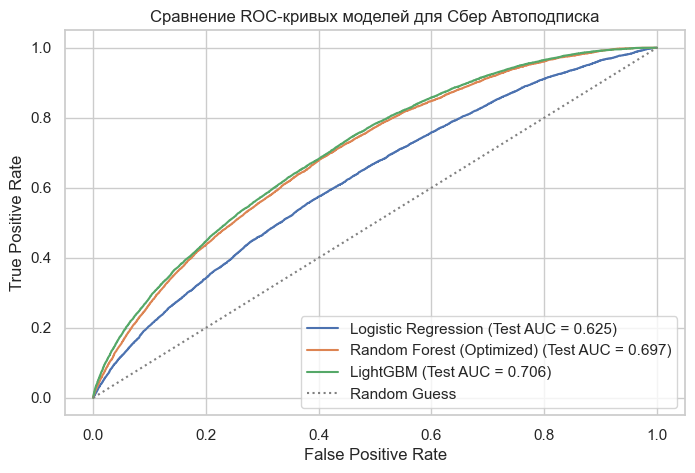

In [19]:
# Параметры для будущих графиков
plt.figure(figsize=(8, 5))

# Цикл обучения
for name, model in models.items():
    print(f"Обучения модели: {name}")
    
    # Обучение
    model.fit(X_train_final, y_train)
    
    # Предсказание вероятностей класса 1
    y_pred_train = model.predict_proba(X_train_final)[:, 1]
    y_pred_test = model.predict_proba(X_test_final)[:, 1]
    
    # Расчет ROC-AUC
    auc_train = roc_auc_score(y_train, y_pred_train)
    auc_test = roc_auc_score(y_test, y_pred_test)
    
    # Сохраняем метрики
    results[name] = {
        "model_object": model,
        "auc_train": auc_train,
        "auc_test": auc_test
    }
    
    print(f"   -> ROC-AUC Train: {auc_train:.4f}")
    print(f"   -> ROC-AUC Test:  {auc_test:.4f}\n")
    
    # Строим кривую для тестовой выборки этой модели
    fpr, tpr, _ = roc_curve(y_test, y_pred_test)
    plt.plot(fpr, tpr, label=f'{name} (Test AUC = {auc_test:.3f})')

# Оформление графика кривых
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess') # Ошибка исправлена здесь
plt.title('Сравнение ROC-кривых моделей для Сбер Автоподписка')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [20]:
# Определение лучшей модели
df_results = pd.DataFrame(results).T[['auc_train', 'auc_test']]
print(df_results)

best_model_name = max(results, key=lambda k: results[k]['auc_test'])
best_auc = results[best_model_name]['auc_test']

print(f"Лучшая модель: {best_model_name}")
print(f"ROC-AUC на тесте: {best_auc:.4f}")

                          auc_train  auc_test
Logistic Regression        0.624904   0.62481
Random Forest (Optimized)  0.715922  0.696821
LightGBM                   0.722659  0.705541
Лучшая модель: LightGBM
ROC-AUC на тесте: 0.7055


In [26]:
# Прописываем полный путь как обычную текстовую строку (с именем файла на конце)
model_filepath = "model/best_lightgbm_model.joblib"

# Получаем объект обученной модели LightGBM
best_lgb_model = results["LightGBM"]["model_object"]

# Сохраняем модель
joblib.dump(best_lgb_model, model_filepath, compress=3)
print("Лучшая модель успешно сохранена")

# Краткий тест-инференс
loaded_model = joblib.load(model_filepath)
test_predictions = loaded_model.predict_proba(X_test_final.head())[:, 1]
print("Модель загружена и готова к работе.")

Лучшая модель успешно сохранена
Модель загружена и готова к работе.


### Матрица корреляций и важность признаков

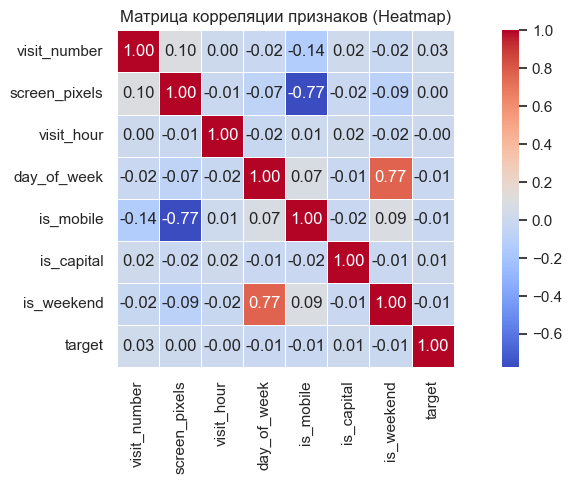

In [22]:
# Матрица корреляций
# Выбираем признаки
corr_cols = ['visit_number', 'screen_pixels', 'visit_hour', 'day_of_week', 
             'is_mobile', 'is_capital', 'is_weekend', 'target']

plt.figure(figsize=(10, 5))
correlation_matrix = df_sessions[corr_cols].corr()

# Строим heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Матрица корреляции признаков (Heatmap)')
plt.tight_layout()
plt.show()

C:\Users\serge\AppData\Local\Temp\ipykernel_11236\4077967110.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Важность (Вклад)', y='Признак', palette='dark:salmon_r')


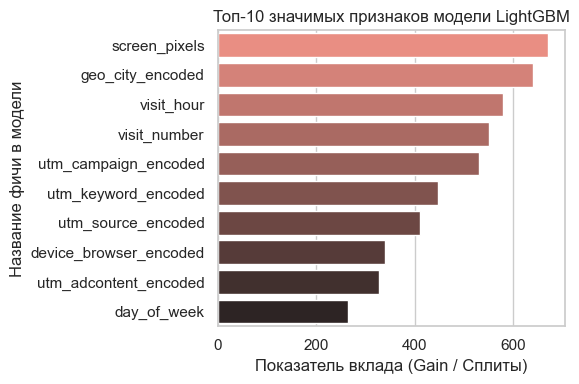

Текстовый анализ важности фичей
                    Признак  Важность (Вклад)
1            screen_pixels               672
14        geo_city_encoded               640
2               visit_hour               580
0             visit_number               551
8     utm_campaign_encoded               531
10     utm_keyword_encoded               448
7       utm_source_encoded               410
13  device_browser_encoded               340
9    utm_adcontent_encoded               328
3              day_of_week               264


In [23]:
# График важности фичей
# Берем лучшую модель
best_model = results["LightGBM"]["model_object"]

importance_df = pd.DataFrame({
    'Признак': X_train_final.columns,
    'Важность (Вклад)': best_model.feature_importances_
}).sort_values(by='Важность (Вклад)', ascending=False).head(10) # Топ-10

plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df, x='Важность (Вклад)', y='Признак', palette='dark:salmon_r')
plt.title('Топ-10 значимых признаков модели LightGBM')
plt.xlabel('Показатель вклада (Gain / Сплиты)')
plt.ylabel('Название фичи в модели')
plt.tight_layout()
plt.show()

print(f'Текстовый анализ важности фичей\n {importance_df}')